# Полносвязные нейронные сети

В этом упражнении мы реализуем полносвязные сети, используя модульный подход. Для каждого слоя мы реализуем функции `forward` и `backward`. Функция `forward` получает входы, веса и другие параметры и возвращает выход, а также объект `cache`, в котором сохраняются данные, необходимые для обратного прохода, например:

```python
def layer_forward(x, w):
  """Получает входы x и веса w"""
  # Выполняем вычисления ...
  z = # ... промежуточные результаты
  # ...
  out = # ... итоговый выход
  cache = (x, w, z, out) # сохраняем всё нужное для backward
  return out, cache
```

Функция `backward` получает производные по выходу и объект `cache`, после чего вычисляет производные по входам и весам:

```python
def layer_backward(dout, cache):
  """Получает производные по выходу и кэш"""
  # Распаковываем значения из cache
  x, w, z, out = cache
  # Выполняем вычисления ...
  dx = # градиент по x
  dw = # градиент по w
  return dx, dw
```

После реализации всех слоёв мы соберём их в двухслойную сеть с архитектурой `affine - relu - affine - softmax`.

# Введение

Ниже предстоит реализовать линейный слой и слой RELU. Как было рассмотрено ранее, на линейном слое выполняется линейное преобразование, а на слое RELU - добавляется нелинейность. Поскольку у нас стоит задача классификации (многоклассовой), то ответы мы будем получать через Softmax

Перед выполнением задания нужно скачать датасет - в папке datasets есть файл с указанием путей для скачивания


In [1]:
# Базовая настройка окружения
import matplotlib.pyplot as plt
import numpy as np
from classifiers.fc_net import *
from utils.data_utils import get_CIFAR10_data
from utils.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from utils.solver import Solver


%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # размер графиков по умолчанию
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

# Автоперезагрузка внешних модулей
%load_ext autoreload
%autoreload 2


def rel_error(x, y):
  """Возвращает максимальную относительную ошибку."""
  return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))


In [2]:
# Загружаем предварительно обработанный CIFAR-10
data = get_CIFAR10_data()
for k, v in list(data.items()):
  print((f"{k}: ", v.shape))


('X_train: ', (49000, 3, 32, 32))
('y_train: ', (49000,))
('X_val: ', (1000, 3, 32, 32))
('y_val: ', (1000,))
('X_test: ', (1000, 3, 32, 32))
('y_test: ', (1000,))


# Полносвязный слой: прямой проход

Откройте файл `utils/layers.py` и реализуйте функцию `affine_forward`.

После этого можно проверить реализацию, запустив следующую ячейку:


In [3]:
# Test the affine_forward function

num_inputs = 2
input_shape = (4, 5, 6)
output_dim = 3

input_size = num_inputs * np.prod(input_shape)
weight_size = output_dim * np.prod(input_shape)

x = np.linspace(-0.1, 0.5, num=input_size).reshape(num_inputs, *input_shape)
w = np.linspace(-0.2, 0.3, num=weight_size).reshape(np.prod(input_shape), output_dim)
b = np.linspace(-0.3, 0.1, num=output_dim)

out, _ = affine_forward(x, w, b)
correct_out = np.array(
  [[1.49834967, 1.70660132, 1.91485297], [3.25553199, 3.5141327, 3.77273342]]
)

# Compare your output with ours. The error should be around e-9 or less.
print("Testing affine_forward function:")
print("difference: ", rel_error(out, correct_out))

Testing affine_forward function:
difference:  9.769849468192957e-10


# Полносвязный слой: обратный проход

Теперь реализуйте функцию `affine_backward` и проверьте её с помощью численной проверки градиента.


In [4]:
# Test the affine_backward function
np.random.seed(47)
x = np.random.randn(10, 2, 3)
w = np.random.randn(6, 5)
b = np.random.randn(5)
dout = np.random.randn(10, 5)

dx_num = eval_numerical_gradient_array(lambda x: affine_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_forward(x, w, b)[0], b, dout)

_, cache = affine_forward(x, w, b)
dx, dw, db = affine_backward(dout, cache)

# The error should be around e-10 or less
print("Testing affine_backward function:")
print("dx error: ", rel_error(dx_num, dx))
print("dw error: ", rel_error(dw_num, dw))
print("db error: ", rel_error(db_num, db))

Testing affine_backward function:
dx error:  4.4313500493386315e-10
dw error:  6.848346707287463e-11
db error:  7.323165923348277e-12


# Активация ReLU: прямой проход

Реализуйте прямой проход для функции активации ReLU в `relu_forward`, а затем проверьте реализацию следующей ячейкой:


In [5]:
# Test the relu_forward function

x = np.linspace(-0.5, 0.5, num=12).reshape(3, 4)

out, _ = relu_forward(x)
correct_out = np.array(
  [
    [
      0.0,
      0.0,
      0.0,
      0.0,
    ],
    [
      0.0,
      0.0,
      0.04545455,
      0.13636364,
    ],
    [
      0.22727273,
      0.31818182,
      0.40909091,
      0.5,
    ],
  ]
)

# Compare your output with ours. The error should be on the order of e-8
print("Testing relu_forward function:")
print("difference: ", rel_error(out, correct_out))

Testing relu_forward function:
difference:  4.999999798022158e-08


# Активация ReLU: обратный проход

Теперь реализуйте обратный проход для ReLU в `relu_backward` и проверьте его с помощью численной проверки градиента:


In [6]:
np.random.seed(47)
x = np.random.randn(10, 10)
dout = np.random.randn(*x.shape)

dx_num = eval_numerical_gradient_array(lambda x: relu_forward(x)[0], x, dout)

_, cache = relu_forward(x)
dx = relu_backward(dout, cache)

# The error should be on the order of e-12
print("Testing relu_backward function:")
print("dx error: ", rel_error(dx_num, dx))

Testing relu_backward function:
dx error:  3.2756399622829256e-12


## Теоретический вопрос 1

Мы просили реализовать только ReLU, но в нейросетях можно использовать много разных функций активации, у каждой есть свои плюсы и минусы. Одна из частых проблем — исчезающие градиенты, когда во время обратного распространения градиент становится равным нулю или очень близким к нулю.

Какие из перечисленных ниже функций страдают от этой проблемы? Если рассматривать функции в одномерном случае, то для каких входных значений это происходит?

1. `sigmoid`
2. `ReLU`
3. `Leaky RELU`

### Ваш ответ:

- sigmoid: страдает от проблемы исчезающих градиентов; из производной сигмоиды (σ(x) · (1 – σ(x))) видно, что при больших по модулю значениях x производная стремится к нулю, что приводит к исчезновению градиентов при обратном распространении.

- ReLU: градиенты исчезают для отрицательных входных значений (x < 0). Если в сети накапливается много отрицательных входов, это может привести к проблеме исчезающих градиентов.

- Leaky RELU: не страдает; маленький наклон (например, 0.01) для отрицательных x специально сделан, чтобы градиент никогда не становился строго нулевым; это позволяет избежать проблемы мёртвых нейронов, и обратное распространение работает даже при отрицательных входах.


# Вывод производной сигмоиды

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

$$
\sigma(x) = (1 + e^{-x})^{-1}
$$

$$
\frac{d}{dx}\sigma(x) = -1 \cdot (1 + e^{-x})^{-2} \cdot \frac{d}{dx}(1 + e^{-x})
$$

$$
\frac{d}{dx}(1 + e^{-x}) = \frac{d}{dx}(1) + \frac{d}{dx}(e^{-x}) = 0 + (-e^{-x}) = -e^{-x}
$$

$$
\sigma'(x) = - (1 + e^{-x})^{-2} \cdot (-e^{-x}) = \frac{e^{-x}}{(1 + e^{-x})^{2}}
$$


# «Сэндвич»-слои

В нейронных сетях часто встречаются типовые комбинации слоёв. Например, полносвязный слой часто сразу сопровождается ReLU. Чтобы не писать один и тот же код много раз, в файле `classifiers/layer_utils.py` определены составные слои.

Сейчас посмотрите на функции `affine_relu_forward` и `affine_relu_backward`, а затем запустите следующую ячейку для численной проверки градиентов обратного прохода:


In [7]:
from classifiers.layer_utils import affine_relu_backward, affine_relu_forward


np.random.seed(47)
x = np.random.randn(2, 3, 4)
w = np.random.randn(12, 10)
b = np.random.randn(10)
dout = np.random.randn(2, 10)

out, cache = affine_relu_forward(x, w, b)
dx, dw, db = affine_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: affine_relu_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_relu_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_relu_forward(x, w, b)[0], b, dout)

# Relative error should be around e-10 or less
print("Testing affine_relu_forward and affine_relu_backward:")
print("dx error: ", rel_error(dx_num, dx))
print("dw error: ", rel_error(dw_num, dw))
print("db error: ", rel_error(db_num, db))

Testing affine_relu_forward and affine_relu_backward:
dx error:  8.56576782308551e-09
dw error:  1.841788802997263e-09
db error:  1.8928925550934774e-11


# Слой потерь: Softmax

Теперь реализуйте функцию потерь и градиент для softmax в функции `softmax_loss` в файле `classifiers/layers.py`.

Корректность реализации можно проверить следующей ячейкой:


In [8]:
np.random.seed(47)
num_classes, num_inputs = 10, 50
x = 0.001 * np.random.randn(num_inputs, num_classes)
y = np.random.randint(num_classes, size=num_inputs)


dx_num = eval_numerical_gradient(lambda x: softmax_loss(x, y)[0], x, verbose=False)
loss, dx = softmax_loss(x, y)

# Test softmax_loss function. Loss should be close to 2.3 and dx error - around e-8
print("\nTesting softmax_loss:")
print("loss: ", loss)
print("dx error: ", rel_error(dx_num, dx))


Testing softmax_loss:
loss:  2.3027306105935414
dx error:  8.338560482466673e-09


# Двухслойная сеть

Откройте файл `classifiers/fc_net.py` и завершите реализацию класса `TwoLayerNet`. Внимательно прочитайте код, чтобы понять API. После этого можно запустить следующую ячейку для проверки реализации.


In [9]:
np.random.seed(47)
N, D, H, C = 3, 5, 50, 7
X = np.random.randn(N, D)
y = np.random.randint(C, size=N)

std = 1e-3
model = TwoLayerNet(input_dim=D, hidden_dim=H, num_classes=C, weight_scale=std)

print("Testing initialization ... ")
W1_std = abs(model.params["W1"].std() - std)
b1 = model.params["b1"]
W2_std = abs(model.params["W2"].std() - std)
b2 = model.params["b2"]
assert W1_std < std / 10, "First layer weights do not seem right"
assert np.all(b1 == 0), "First layer biases do not seem right"
assert W2_std < std / 10, "Second layer weights do not seem right"
assert np.all(b2 == 0), "Second layer biases do not seem right"

print("Testing test-time forward pass ... ")
model.params["W1"] = np.linspace(-0.7, 0.3, num=D * H).reshape(D, H)
model.params["b1"] = np.linspace(-0.1, 0.9, num=H)
model.params["W2"] = np.linspace(-0.3, 0.4, num=H * C).reshape(H, C)
model.params["b2"] = np.linspace(-0.9, 0.1, num=C)
X = np.linspace(-5.5, 4.5, num=N * D).reshape(D, N).T
scores = model.loss(X)
correct_scores = np.asarray(
  [
    [
      11.53165108,
      12.2917344,
      13.05181771,
      13.81190102,
      14.57198434,
      15.33206765,
      16.09215096,
    ],
    [
      12.05769098,
      12.74614105,
      13.43459113,
      14.1230412,
      14.81149128,
      15.49994135,
      16.18839143,
    ],
    [
      12.58373087,
      13.20054771,
      13.81736455,
      14.43418138,
      15.05099822,
      15.66781506,
      16.2846319,
    ],
  ]
)
scores_diff = np.abs(scores - correct_scores).sum()
assert scores_diff < 1e-6, "Problem with test-time forward pass"

print("Testing training loss (no regularization)")
y = np.asarray([0, 5, 1])
loss, grads = model.loss(X, y)
correct_loss = 3.4702243556
assert abs(loss - correct_loss) < 1e-10, "Problem with training-time loss"

model.reg = 1.0
loss, grads = model.loss(X, y)
correct_loss = 26.5948426952
assert abs(loss - correct_loss) < 1e-10, "Problem with regularization loss"

# Errors should be around e-7 or less
for reg in [0.0, 0.7]:
  print("Running numeric gradient check with reg = ", reg)
  model.reg = reg
  loss, grads = model.loss(X, y)

  for name in sorted(grads):

    def f(_):
      return model.loss(X, y)[0]

    grad_num = eval_numerical_gradient(f, model.params[name], verbose=False)
    print(f"{name} relative error: {rel_error(grad_num, grads[name]):.2e}")

Testing initialization ... 
Testing test-time forward pass ... 
Testing training loss (no regularization)
Running numeric gradient check with reg =  0.0
W1 relative error: 1.83e-08
W2 relative error: 3.20e-10
b1 relative error: 9.83e-09
b2 relative error: 4.33e-10
Running numeric gradient check with reg =  0.7
W1 relative error: 2.53e-07
W2 relative error: 2.85e-08
b1 relative error: 1.56e-08
b2 relative error: 9.09e-10


# Solver

Откройте файл `utils/solver.py` и ознакомьтесь с его API. Затем с помощью объекта `Solver` обучите `TwoLayerNet`, чтобы добиться примерно точности на валидационной выборке как минимум более 35%. В качестве оптимизатора можно взять на данном уже реализованный в optim.py, либо написать свой


In [10]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10

data_flattened = {
  "X_train": data["X_train"].reshape(data["X_train"].shape[0], -1),
  "y_train": data["y_train"],
  "X_val": data["X_val"].reshape(data["X_val"].shape[0], -1),
  "y_val": data["y_val"],
  "X_test": data["X_test"].reshape(data["X_test"].shape[0], -1),
  "y_test": data["y_test"],
}

model = TwoLayerNet(
  input_dim=input_size,
  hidden_dim=hidden_size,
  num_classes=num_classes,
  weight_scale=1e-3,
  reg=0.0,
)

solver = Solver(
  model,
  data_flattened,
  update_rule="sgd",
  optim_config={"learning_rate": 1e-3},
  lr_decay=0.95,
  batch_size=100,
  num_epochs=10,
  print_every=100,
  verbose=True,
)

solver.train()
print(f"Best validation accuracy: {solver.best_val_acc:.3f}")

(Iteration 1 / 4900) loss: 2.305471
(Epoch 0 / 10) train acc: 0.072000; val_acc: 0.091000
(Iteration 101 / 4900) loss: 1.795101
(Iteration 201 / 4900) loss: 1.743232
(Iteration 301 / 4900) loss: 1.715798
(Iteration 401 / 4900) loss: 1.735074
(Epoch 1 / 10) train acc: 0.469000; val_acc: 0.416000
(Iteration 501 / 4900) loss: 1.534318
(Iteration 601 / 4900) loss: 1.489492
(Iteration 701 / 4900) loss: 1.629021
(Iteration 801 / 4900) loss: 1.637150
(Iteration 901 / 4900) loss: 1.463877
(Epoch 2 / 10) train acc: 0.490000; val_acc: 0.451000
(Iteration 1001 / 4900) loss: 1.357448
(Iteration 1101 / 4900) loss: 1.459090
(Iteration 1201 / 4900) loss: 1.374484
(Iteration 1301 / 4900) loss: 1.451601
(Iteration 1401 / 4900) loss: 1.377411
(Epoch 3 / 10) train acc: 0.488000; val_acc: 0.469000
(Iteration 1501 / 4900) loss: 1.433651
(Iteration 1601 / 4900) loss: 1.526539
(Iteration 1701 / 4900) loss: 1.519323
(Iteration 1801 / 4900) loss: 1.343486
(Iteration 1901 / 4900) loss: 1.413985
(Epoch 4 / 10) t

# Отладка обучения

С параметрами по умолчанию точность на валидации должна получиться около `0.36`. Это не очень высокий результат.

Один способ понять, что идёт не так, — построить графики функции потерь и точности на обучающей и валидационной выборках во время оптимизации.

Другой способ — визуализировать веса, которые выучила сеть в первом слое. В задачах компьютерного зрения первый слой часто начинает выделять простые шаблоны: границы, цветовые контрасты, текстуры. Если веса выглядят как шум, это намекает на проблемы с настройкой обучения.


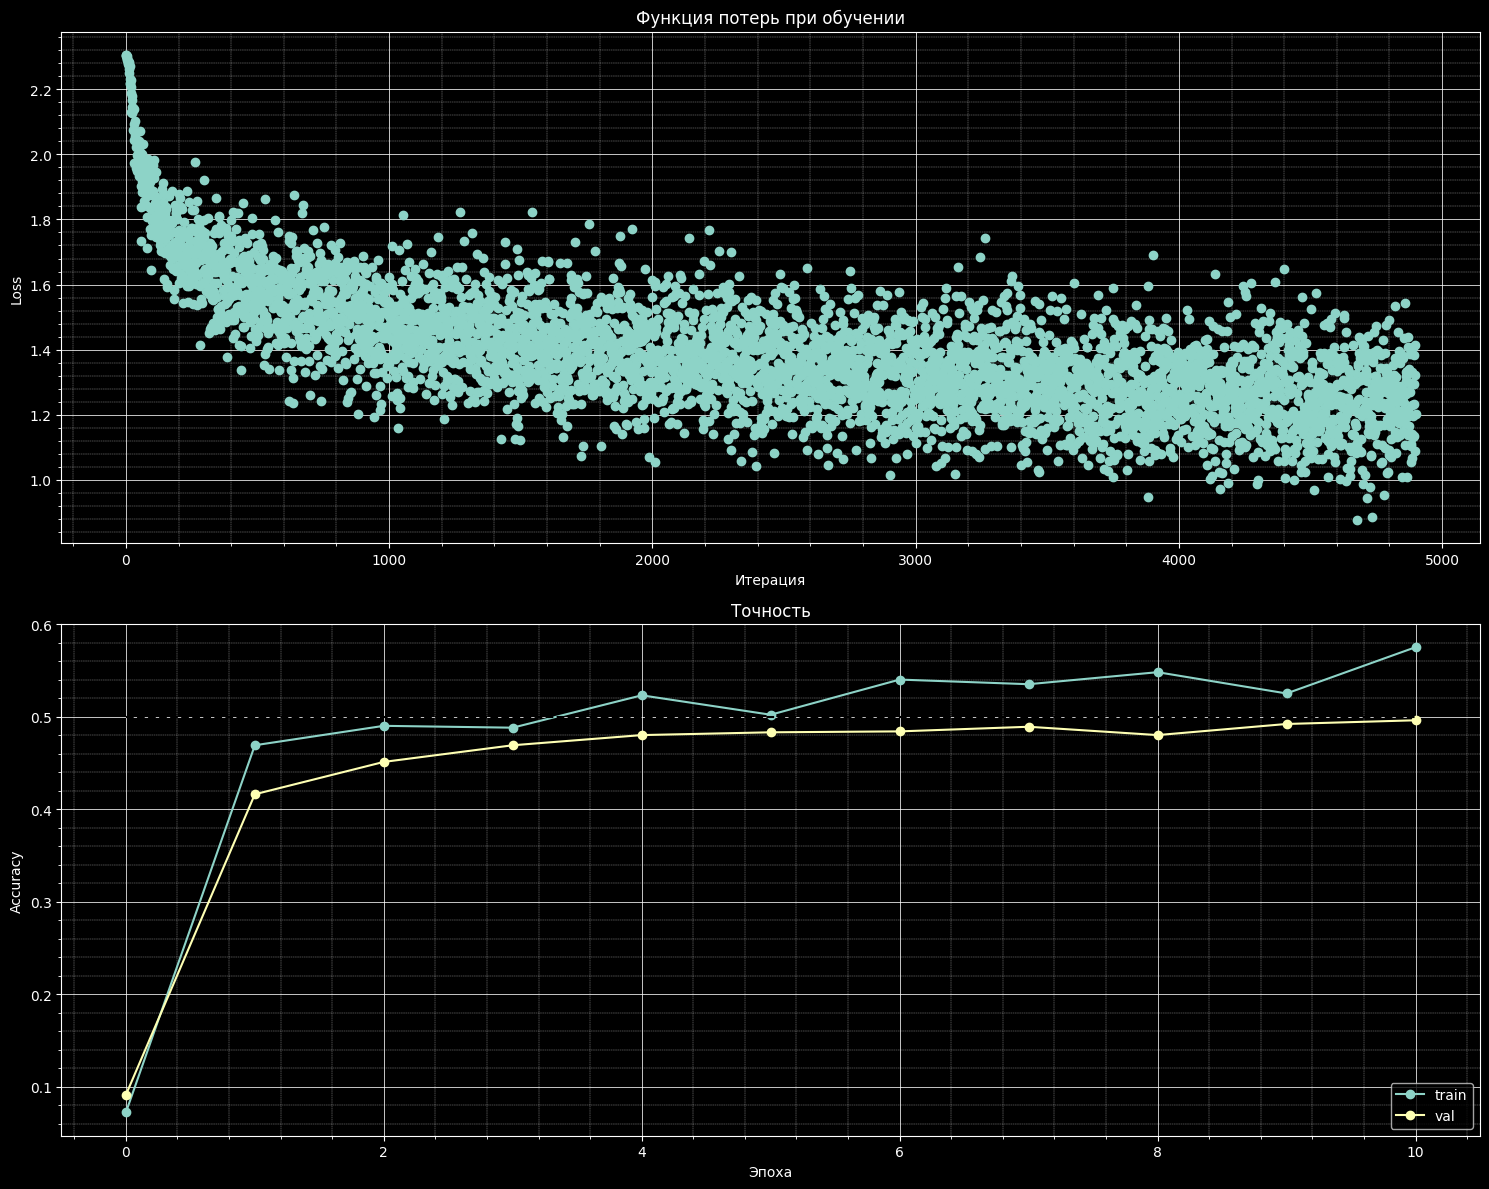

In [11]:
from matplotlib.ticker import AutoMinorLocator


fig = plt.figure(figsize=(15, 12))

plt.subplot(2, 1, 1)
plt.title("Функция потерь при обучении")
plt.plot(solver.loss_history, "o")
plt.xlabel("Итерация")
plt.ylabel("Loss")
plt.minorticks_on()
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(5))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))
plt.grid(which="minor", linestyle="--", linewidth=0.3, alpha=0.7)
plt.grid(which="major", linewidth=0.6, alpha=0.9)

plt.subplot(2, 1, 2)
plt.title("Точность")
plt.plot(solver.train_acc_history, "-o", label="train")
plt.plot(solver.val_acc_history, "-o", label="val")
plt.plot([0.5] * len(solver.val_acc_history), "k--")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.minorticks_on()
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(5))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))
plt.grid(which="minor", linestyle="--", linewidth=0.3, alpha=0.7)
plt.grid(which="major", linewidth=0.6, alpha=0.9)

plt.tight_layout()
plt.show()

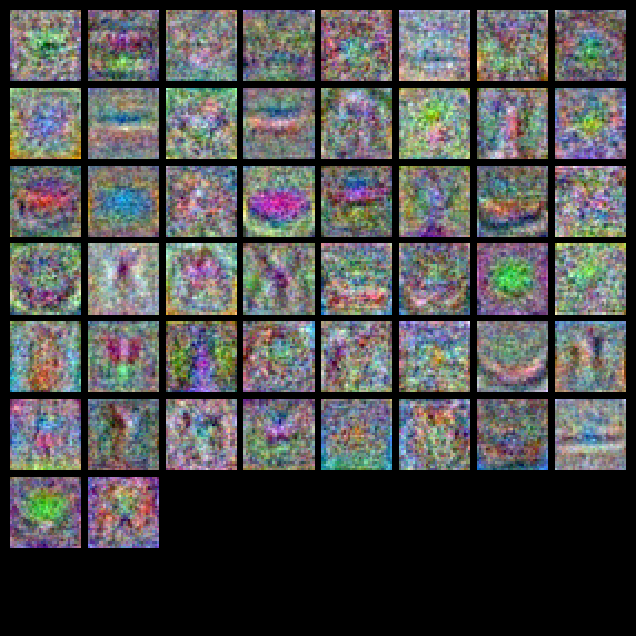

In [12]:
from utils.vis_utils import visualize_grid


# Визуализация весов первого слоя сети
def show_net_weights(net):
  W1 = net.params["W1"]
  W1 = W1.reshape(3, 32, 32, -1).transpose(3, 1, 2, 0)
  plt.imshow(visualize_grid(W1, padding=3).astype("uint8"))
  plt.gca().axis("off")
  plt.show()


show_net_weights(model)


# Подбор гиперпараметров

**Что здесь не так?** По графикам выше видно, что функция потерь убывает почти линейно. Это часто говорит о том, что скорость обучения слишком мала. Кроме того, между обучающей и валидационной точностью почти нет разрыва, а значит, модель, скорее всего, имеет недостаточную ёмкость и её стоит увеличить.

С другой стороны, слишком большая модель может начать переобучаться: тогда обучающая точность станет заметно выше валидационной. Ваша цель — подобрать такие гиперпараметры, чтобы получить качество выше `48%` на валидации.
При выборе варьируемых гиперпараметров модно отталкиваться от параметров TwoLayerNet


In [13]:
best_model = None
best_val = -1

# Параметры для поиска
learning_rates = [1e-3, 2e-3, 5e-3, 1e-2]
hidden_sizes = [50, 100, 200]
regs = [0, 0.1, 0.5]

for lr in learning_rates:
  for hidden in hidden_sizes:
    for reg in regs:
      model = TwoLayerNet(
        input_dim=3072, hidden_dim=hidden, num_classes=10, weight_scale=1e-3, reg=reg
      )

      solver = Solver(
        model,
        data_flattened,
        update_rule="sgd",
        optim_config={"learning_rate": lr},
        lr_decay=0.95,
        batch_size=100,
        num_epochs=5,
        verbose=False,
      )
      solver.train()

      val_acc = solver.best_val_acc
      if val_acc > best_val:
        best_val = val_acc
        best_model = model
        print(f"LR={lr}, Hidden={hidden}, Reg={reg} -> Val Acc: {val_acc:.3f}")

print(f"\nBest validation accuracy: {best_val:.3f}")


LR=0.001, Hidden=50, Reg=0 -> Val Acc: 0.499
LR=0.001, Hidden=50, Reg=0.5 -> Val Acc: 0.509
LR=0.001, Hidden=100, Reg=0 -> Val Acc: 0.511


c:\UL\Programs\Python\semesters\5\machine_learning\DeepLearning\Homework\classifiers\fc_net.py:290: RuntimeWarning: divide by zero encountered in log
  loss = -np.sum(np.log(probs[np.arange(N), y])) / N
c:\UL\Programs\Python\semesters\5\machine_learning\DeepLearning\Homework\classifiers\fc_net.py:263: RuntimeWarning: overflow encountered in matmul
  scores = a1 @ W2 + b2
c:\UL\Programs\Python\semesters\5\machine_learning\DeepLearning\Homework\classifiers\fc_net.py:285: RuntimeWarning: overflow encountered in subtract
  shifted = scores - np.max(scores, axis=1, keepdims=True)
c:\UL\Programs\Python\semesters\5\machine_learning\DeepLearning\Homework\classifiers\fc_net.py:285: RuntimeWarning: invalid value encountered in subtract
  shifted = scores - np.max(scores, axis=1, keepdims=True)



Best validation accuracy: 0.511


# Проверка лучшей модели

Запустите лучшую найденную модель на валидационной и тестовой выборках. Нужно получить более `48%` точности и на валидации, и на тесте.


In [14]:
y_val_pred = np.argmax(best_model.loss(data_flattened["X_val"]), axis=1)
print("Точность на validation: ", (y_val_pred == data_flattened["y_val"]).mean())

Точность на validation:  0.511


In [15]:
y_test_pred = np.argmax(best_model.loss(data_flattened["X_test"]), axis=1)
print("Точность на test: ", (y_test_pred == data["y_test"]).mean())


Точность на test:  0.509


In [16]:
# Сохраняем лучшую модель
best_model.save("best_two_layer_net.npy")


best_two_layer_net.npy saved.


## Теоретический вопрос 2

После обучения нейросетевого классификатора может оказаться, что точность на тесте заметно ниже, чем на обучении. Как можно уменьшить этот разрыв? Выберите все подходящие варианты.

1. Обучать на более крупном датасете.
2. Добавить больше скрытых нейронов.
3. Увеличить силу регуляризации.
4. Ничего из перечисленного.

### Ваш ответ

- Обучать на более крупном датасете: больше данных улучшают обобщающую способность, модель меньше подстраивается под шум в обучающей выборке.
- Увеличить силу регуляризации: помогает бороться с переобучением, которое как раз и даёт большой разрыв между train и test.
